In [1]:
from google.colab import files
uploaded = files.upload()
# Select all 4 CSV files

Saving clap.csv to clap.csv
Saving silence.csv to silence.csv
Saving snap.csv to snap.csv
Saving tap.csv to tap.csv


In [2]:
import pandas as pd
import numpy as np

dfs = []
for fname in uploaded.keys():
    df = pd.read_csv(fname)
    df = df[~df['label'].astype(str).str.startswith('#')]
    df = df[df['label'] != 'label']
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

mfcc_cols = [f'mfcc{i}' for i in range(13)]
data[mfcc_cols] = data[mfcc_cols].astype(float)

print("Total rows:", len(data))
print(data['label'].value_counts())

Total rows: 240
label
clap       60
silence    60
snap       60
tap        60
Name: count, dtype: int64


In [3]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

mfcc_cols = [f'mfcc{i}' for i in range(13)]
X = data[mfcc_cols].values.astype(np.float32)
y = data['label'].values

le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Class order:", list(le.classes_))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc, test_size=0.2,
    random_state=42, stratify=y_enc)

print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("Feature shape:", X.shape)

Class order: ['clap', 'silence', 'snap', 'tap']
Train size: 192
Test size: 48
Feature shape: (240, 13)


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Reshape for CNN — (samples, 13, 1)
X_train_cnn = X_train.reshape(-1, 13, 1)
X_test_cnn  = X_test.reshape(-1, 13, 1)

model = models.Sequential([
    layers.Input(shape=(13, 1)),
    layers.Conv1D(32, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(le.classes_), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

early_stop = callbacks.EarlyStopping(
    patience=10, restore_best_weights=True)

history = model.fit(
    X_train_cnn, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 13, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 13, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 6, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 6, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,140 (43.52 KB)

 Trainable params: 10,948 (42.77 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.2941 - loss: 1.5112 - val_accuracy: 0.3077 - val_loss: 1.3726
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5490 - loss: 1.0887 - val_accuracy: 0.6154 - val_loss: 1.3335
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5882 - loss: 1.0328 - val_accuracy: 0.5897 - val_loss: 1.3068
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6797 - loss: 0.8986 - val_accuracy: 0.6410 - val_loss: 1.2946
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7386 - loss: 0.7861 - val_accuracy: 0.6410 - val_loss: 1.2806
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7516 - loss: 0.7558 - val_accuracy: 0.5385 - val_loss: 1.2646
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7712 - loss: 0.6880 - val_accuracy: 0.4615 - val_loss: 1.2578
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8039 - loss: 0.6099 - val_accuracy: 0.4615 -

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 224ms/step


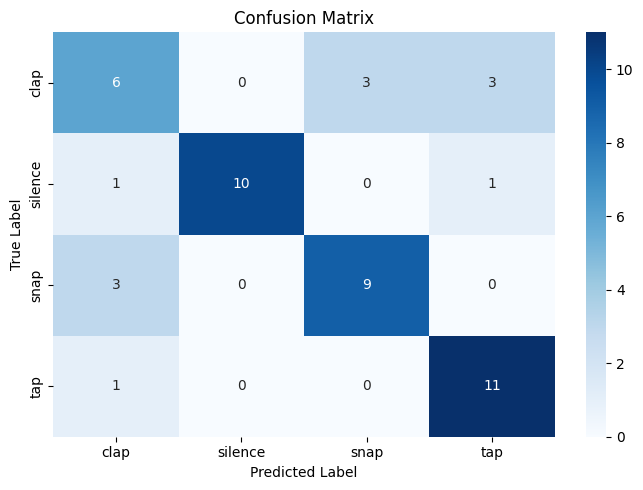

              precision    recall  f1-score   support

        clap       0.55      0.50      0.52        12
     silence       1.00      0.83      0.91        12
        snap       0.75      0.75      0.75        12
         tap       0.73      0.92      0.81        12

    accuracy                           0.75        48
   macro avg       0.76      0.75      0.75        48
weighted avg       0.76      0.75      0.75        48



In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_pred = np.argmax(model.predict(X_test_cnn), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred,
      target_names=le.classes_))

In [6]:
print("// =============================================")
print("// PASTE THIS INTO YOUR ARDUINO SKETCH")
print("// =============================================\n")

print(f"const int NUM_FEATURES = {X.shape[1]};")
print(f"const int NUM_CLASSES = {len(le.classes_)};")
names = ", ".join([f'"{c}"' for c in le.classes_])
print(f'const char* CLASS_NAMES[] = {{{names}}};\n')

print(f"const float SCALER_MEAN[{X.shape[1]}] = {{")
vals = ", ".join([f"{v:.6f}f" for v in scaler.mean_])
print(f"  {vals}")
print("};\n")

print(f"const float SCALER_SCALE[{X.shape[1]}] = {{")
vals = ", ".join([f"{v:.6f}f" for v in scaler.scale_])
print(f"  {vals}")
print("};\n")

print("// Class order:", list(le.classes_))

// =============================================
// PASTE THIS INTO YOUR ARDUINO SKETCH
// =============================================

const int NUM_FEATURES = 13;
const int NUM_CLASSES = 4;
const char* CLASS_NAMES[] = {"clap", "silence", "snap", "tap"};

const float SCALER_MEAN[13] = {
  -77.154928f, 5.493569f, 2.100413f, 2.963457f, 2.878046f, 2.072300f, 1.830021f, 1.130178f, 1.355042f, 1.300416f, 0.991215f, 0.823830f, 0.711002f
};

const float SCALER_SCALE[13] = {
  21.870116f, 4.170815f, 2.258736f, 1.435492f, 1.637160f, 1.336571f, 1.183367f, 0.888916f, 0.935136f, 0.848852f, 0.763377f, 0.736158f, 0.667156f
};

// Class order: ['clap', 'silence', 'snap', 'tap']


In [7]:
from google.colab import files

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

print(f"Model size: {len(tflite_model)} bytes")

with open('keyword_model.h', 'w') as f:
    f.write('#pragma once\n\n')
    f.write(f'const unsigned int model_tflite_len = {len(tflite_model)};\n')
    f.write('__attribute__((aligned(8))) const unsigned char model_tflite[] = {\n  ')
    hex_data = ['0x{:02x}'.format(b) for b in tflite_model]
    f.write(',\n  '.join(
        ', '.join(hex_data[i:i+12]) for i in range(0, len(hex_data), 12)
    ))
    f.write('\n};\n')

files.download('keyword_model.h')
print("keyword_model.h downloaded!")

Saved artifact at '/tmp/tmpomln71g1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 13, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  135480315956112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135480315958416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135480315960336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135480315958032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135480315957840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135480315959376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135480315960528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135480315960912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135480315962064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135480315962256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135480315960144: Ten

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

keyword_model.h downloaded!


In [8]:
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()
inp = interpreter.get_input_details()
out = interpreter.get_output_details()

test_input = np.zeros((1, 13, 1), dtype=np.float32)
interpreter.set_tensor(inp[0]['index'], test_input)
interpreter.invoke()
result = interpreter.get_tensor(out[0]['index'])

print("Test output:", result)
print("Any NaN:", np.any(np.isnan(result)))
print("Sum of probabilities:", np.sum(result))
print("\nIf Any NaN is False and Sum close to 1.0 — model is good!")

Test output: [[9.6624136e-01 3.3456672e-02 2.8027405e-04 2.1695019e-05]]
Any NaN: False
Sum of probabilities: 1.0

If Any NaN is False and Sum close to 1.0 — model is good!


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [9]:
import numpy as np

# Simulate what Arduino computes — a scaled MFCC vector
# Use one real row from your dataset
sample = X_test[0]  # already scaled
print("Scaled input:", sample)

# Reshape for model
sample_cnn = sample.reshape(1, 13, 1).astype(np.float32)

interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()
inp = interpreter.get_input_details()
out = interpreter.get_output_details()

interpreter.set_tensor(inp[0]['index'], sample_cnn)
interpreter.invoke()
result = interpreter.get_tensor(out[0]['index'])

print("Predicted probs:", result)
print("Predicted class:", le.classes_[np.argmax(result)])
print("True class:", le.classes_[y_test[0]])

Scaled input: [ 0.5910673   1.1351514   1.2214779   1.1833879   0.52027446  0.32798317
  0.47544202  1.2069225   0.38592613 -0.60479957  0.05901428  0.8070105
 -0.03565751]
Predicted probs: [[0.4927513  0.0012254  0.07619229 0.429831  ]]
Predicted class: clap
True class: clap


In [10]:
print("Input shape:", inp[0]['shape'])
print("Input dtype:", inp[0]['dtype'])

Input shape: [ 1 13  1]
Input dtype: <class 'numpy.float32'>


In [11]:
print("Input shape:", inp[0]['shape'])  # should be [1, 13, 1]
print("Input size:", inp[0]['shape'][0] * inp[0]['shape'][1] * inp[0]['shape'][2])

Input shape: [ 1 13  1]
Input size: 13


In [12]:
test_zero = np.zeros((1, 13, 1), dtype=np.float32)
interpreter.set_tensor(inp[0]['index'], test_zero)
interpreter.invoke()
result = interpreter.get_tensor(out[0]['index'])
print("Zero input probs:", result)

Zero input probs: [[9.6624136e-01 3.3456672e-02 2.8027405e-04 2.1695019e-05]]


In [13]:
# Print first 5 rows of each class so you can compare
for label in le.classes_:
    idx = np.where(y == label)[0][0]
    print(f"{label}: {X_scaled[idx]}")

clap: [-0.7777428  -0.98912275 -1.0044239  -1.0459621  -0.01363019  1.2839999
  0.10721809  0.9048747   1.8818163   0.0782688   1.0694675   2.1384265
  0.43027082]
silence: [-0.6936395  -0.8513941  -0.97978127 -0.14068988 -0.0573394   0.16256881
  0.9829011   1.1033524   0.8802039   0.95816505  0.45909694  1.2074927
  1.6485792 ]
snap: [-0.34005648 -0.9436859  -0.6254973  -0.0397161   0.7063601  -0.6411981
 -0.01559591  1.3357794  -0.17614487 -1.1105602   0.92868656  0.2318687
  0.05986136]
tap: [ 1.4319161   1.6993148   0.6887889   0.8554314  -1.7971886   0.7509882
 -1.7672008  -1.4142071  -2.1117494  -0.45484877 -0.17129657  0.90297365
  0.08794627]
